## Human/Machine/Other Decisions

Should I users/machines/others or combinaitons of these. This notebook will provide the reserach and evidence for which one to choose.


In [5]:
# Packages 
import polars as pl
import matplotlib.pyplot as plt

In [6]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

#df = pl.scan_csv("../auth.txt.gz",has_header=False,separator=",",new_columns= ['time','src_user','dest_user','src_comp','dest_comp','auth_type','logon_type','auth_orientation','outcome'])

In [7]:
# First 5 rows of dataset
df.show(5)

time,src_user,dest_user,src_comp,dest_comp,auth_type,logon_type,auth_orientation,outcome
i64,str,str,str,str,str,str,str,str
1,"""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success"""
1,"""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success"""
1,"""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success"""
1,"""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success"""
1,"""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success"""


In [8]:
df.filter(pl.col("src_user").str.contains("NETWORK SERVICE")).limit(5).collect()

time,src_user,dest_user,src_comp,dest_comp,auth_type,logon_type,auth_orientation,outcome
i64,str,str,str,str,str,str,str,str
17,"""NETWORK SERVICE@C4515""","""NETWORK SERVICE@C4515""","""C4515""","""C4515""","""Negotiate""","""Service""","""LogOn""","""Success"""
24,"""NETWORK SERVICE@C4273""","""NETWORK SERVICE@C4273""","""C4273""","""C4273""","""Negotiate""","""Service""","""LogOn""","""Success"""
29,"""NETWORK SERVICE@C4023""","""NETWORK SERVICE@C4023""","""C4023""","""C4023""","""Negotiate""","""Service""","""LogOn""","""Success"""
31,"""NETWORK SERVICE@C3935""","""NETWORK SERVICE@C3935""","""C3935""","""C3935""","""Negotiate""","""Service""","""LogOn""","""Success"""
32,"""NETWORK SERVICE@C3124""","""NETWORK SERVICE@C3124""","""C3124""","""C3124""","""Negotiate""","""Service""","""LogOn""","""Success"""


In [ ]:
# Adding type of user to columns
df = df.with_columns(
    pl.col("src_user")
      .str.strip_chars('"')
      .str.split("@").list.first()
      .alias("src_identifier")
).with_columns(
    pl.when(pl.col("src_identifier").str.ends_with("$"))
      .then(pl.lit("machine"))
      .when(pl.col("src_identifier").str.starts_with("U"))
      .then(pl.lit("user"))
      .otherwise(pl.lit("other"))
      .alias("src_type")
)

In [6]:
# What are the different type of source users
df.filter(pl.col("src_type") == "other") \
  .select("src_identifier") \
  .unique() \
  .collect(engine="streaming")

src_identifier
str
"""NETWORK SERVICE"""
"""LOCAL SERVICE"""
"""SYSTEM"""
"""ANONYMOUS LOGON"""


The distinct source users are:

USERS, MACHINES, SYSTEM, LOCAL SERVICE, ANONYMOUS LOGON, NETWORK SERVICE

In [7]:
df.group_by("src_type").len().sort("len", descending=True).collect(engine="streaming")

src_type,len
str,u64
"""machine""",633193503
"""user""",341692445
"""other""",76544511


633193503 (~600 million) machine users.

341692445 (~ 300 million) human users.

76544511 (~ 76 million) others

In [8]:
df.filter(pl.col("src_type") == "other") \
  .group_by("src_identifier").len() \
  .sort("len", descending=True) \
  .collect(engine="streaming")

src_identifier,len
str,u64
"""NETWORK SERVICE""",39754826
"""ANONYMOUS LOGON""",33534047
"""LOCAL SERVICE""",2870066
"""SYSTEM""",385572


39754826 (~39 million) NETWORK SERVICE	

33534047 (~ 33 million) ANONYMOUS LOGON

2870066 (~ 280k) LOCAL SERVICE

385572 (~ 38k) SYSTEM

Failure rates are so low, that looking at failure rates across users/machines/others doesn't yield anything useful.

In [9]:
df.group_by("outcome").len().collect(engine="streaming")

outcome,len
str,u64
"""Success""",1038590151
"""Fail""",12840308


1038590151 (~ 1 billion) succesful events

12840308 (~12 million) failure events

Distinct destination computers

machine"	14982
"user"	15591
"other"	12788

In [10]:
# %%
# Aggregate counts per hour per src_type
ts = df.with_columns(
    (pl.col("time") // 3600).alias("hour")     # 3600 sec = 1 hr; use 86400 for daily
).group_by("hour", "src_type").len() \
 .sort("hour") \
 .collect(engine="streaming")

ts

hour,src_type,len
i64,str,u64
0,"""user""",83931
0,"""machine""",252602
0,"""other""",13162
1,"""user""",85036
1,"""machine""",252210
…,…,…
1390,"""machine""",463979
1390,"""other""",85582
1391,"""machine""",462006


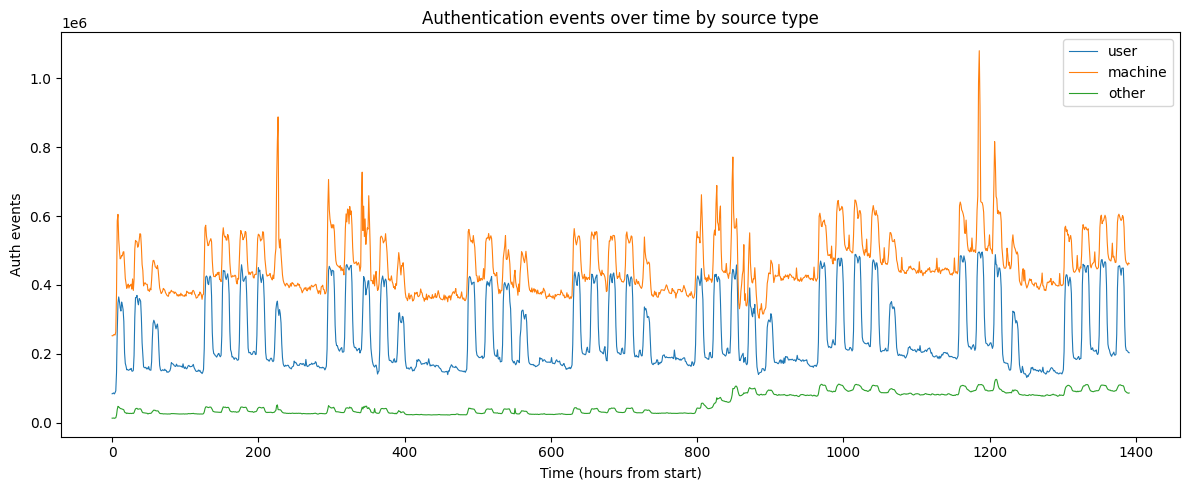

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

for t in ["user", "machine", "other"]:
    sub = ts.filter(pl.col("src_type") == t).sort("hour")
    ax.plot(sub["hour"], sub["len"], label=t, linewidth=0.8)

ax.set_xlabel("Time (hours from start)")
ax.set_ylabel("Auth events")
ax.set_title("Authentication events over time by source type")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# %%
# Per-identity distinct dest_comp counts, one DataFrame per src_type
per_identity = {}
for t in ["user", "machine", "other"]:
    per_identity[t] = (
        df.filter(pl.col("src_type") == t)
          .group_by("src_identifier")
          .agg(pl.col("dest_comp").n_unique().alias("distinct_dest_comps"))
          .collect(engine="streaming")
    )

In [13]:
# %%
# (4) Identity counts and summary stats per src_type
pl.DataFrame([
    {
        "src_type": t,
        "num_identities": d.height,
        "mean_dest_comps": d["distinct_dest_comps"].mean(),
        "median_dest_comps": d["distinct_dest_comps"].median(),
        "max_dest_comps": d["distinct_dest_comps"].max(),
    }
    for t, d in per_identity.items()
])

src_type,num_identities,mean_dest_comps,median_dest_comps,max_dest_comps
str,i64,f64,f64,i64
"""user""",12414,27.518044,25.0,11764
"""machine""",13883,20.336167,21.0,344
"""other""",4,8156.0,8149.0,12564


shape: (3, 5)
src_type	num_identities	mean_dest_comps	median_dest_comps	max_dest_comps
str	i64	f64	f64	i64
"user"	12414	27.518044	25.0	11764
"machine"	13883	20.336167	21.0	344
"other"	4	8156.0	8149.0	12564


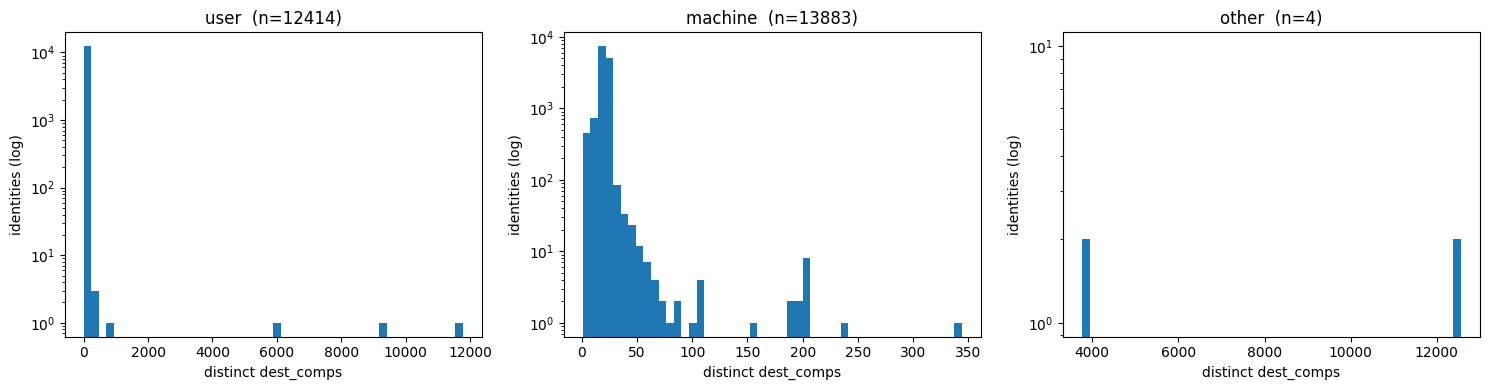

In [14]:
# %%
# (3) Histograms of distinct_dest_comps per identity, one per src_type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, t in zip(axes, ["user", "machine", "other"]):
    vals = per_identity[t]["distinct_dest_comps"].to_numpy()
    ax.hist(vals, bins=50)
    ax.set_yscale("log")          # counts vary wildly; log makes the tail visible
    ax.set_title(f"{t}  (n={len(vals)})")
    ax.set_xlabel("distinct dest_comps")
    ax.set_ylabel("identities (log)")

plt.tight_layout()
plt.show()

In [17]:
# Where do human users authenticate to?
df.filter(pl.col("src_type") == "user") \
  .group_by("dest_type").len() \
  .sort("len", descending=True) \
  .collect(engine="streaming")

dest_type,len
str,u64
"""user""",338407021
"""machine""",3135428
"""other""",149996


On top of the EDA, we have that previous papers have removed machine accounts etc.
- A. D. Kent, L. M. Liebrock, and J. C. Neil, “Authentication graphs:
Analyzing user behavior within an enterprise network,” Computers &
Security, vol. 48, pp. 150–166, 2015.
- https://par.nsf.gov/servlets/purl/10344249